# 03-1. k-최근접 이웃 회귀(K-NN Regression)

## 0. 개념 정리

### 0.1. 지도 학습 알고리즘: 분류와 회귀
- **분류**: 샘플을 몇 개의 클래스 중 하나로 **분류**하는 문제
- **회귀**: 임의의 어떤 숫자를 **예측**하는 문제로, 따라서 타깃값도 임의의 수치가 됨

### 0.2. k-최근접 이웃 회귀 알고리즘
- k-최근접 이웃 알고리즘을 사용해 회귀 문제를 품
- 가장 가까운 이웃 샘플을 찾고 이 샘플들의 타깃값을 평균하여 예측으로 삼음

### 0.3. 결정계수(R²)

- 대표적인 회귀 문제의 성능 측정 도구임
- 1에 가까울수록 좋고, 0에 가깝다면 성능이 나쁜 모델임
- 모델이 타깃의 평균 정도를 예측하는 수준이면 결정계수는 0에 가까움
- 모델이 타깃을 아주 잘 예측하면 결정계수는 1에 가까움
- 결정계수는 음수가 될 수도 있음 (모델이 평균보다도 못할 때)

### 0.4. 과대 적합 vs 과소 적합
- **과대 적합**: 모델의 훈련 세트 성능이 테스트 세트 성능보다 훨씬 높을 때 일어남. 모델이 훈련 세트에 너무 집착해서 데이터에 내재된 거시적인 패턴을 감지하지 못함
- **과소 적합**: 훈련 세트와 테스트 세트 성능이 모두 동일하게 낮거나 테스트 세트 성능이 오히려 더 높을 때 일어남. 이런 경우 더 복잡한 모델을 사용해 훈련 세트에 잘 맞는 모델을 만들어야 함
    - 훈련 세트에 대한 점수가 테스트 세트에 대한 점수보다 낮다면 과소적합이 발생했다고 볼 수 있음

### 0.5. 모델 평가 점수 해석
- 사이킷런은 회귀 모델의 점수로 R²(결정계수) 값을 반환함
- R² 값은 1에 가까울수록 좋음
- 정량적인 평가를 하고 싶다면 다른 평가 도구(대표적으로 절댓값 오차)를 사용할 수 있음
- 모델을 훈련하고 나서 훈련 세트와 테스트 세트에 대해 모두 평가 점수를 구할 수 있음
- 훈련 세트의 점수와 테스트 세트의 점수 차이가 크면 좋지 않음
- 일반적으로 훈련 세트의 점수가 테스트 세트보다 조금 더 높음

### 0.6. 과대 적합 vs 과소 적합 해결

| 상황 | 해결 방법 | k-최근접 이웃의 경우 |
|------|----------|------------------|
| 과대 적합 | 모델을 덜 복잡하게 | k 값을 늘림 |
| 과소 적합 | 모델을 더 복잡하게 | k 값을 줄임 |


### 0.7. scikit-learn 주요 클래스와 함수
- **`KNeighborsRegressor`**
    - k-최근접 이웃 회귀 모델을 만드는 사이킷런 클래스임
    - n_neighbors 매개변수로 이웃의 개수를 지정함 (기본값 5)
    - 다른 매개변수는 KNeighborsClassifier 클래스와 거의 동일함

- **`mean_absolute_error()`**
    - 회귀 모델의 평균 절댓값 오차를 계산함
    - 첫 번째 매개변수는 타깃, 두 번째 매개변수는 예측값을 전달함
    - 타깃과 예측을 뺀 값을 제곱한 다음 전체 샘플에 대해 평균한 값을 반환함
    - 이와 비슷한 함수로는 평균 제곱 오차를 계산하는 mean_squared_error()가 있음


### 0.8. numpy 주요 함수
- **`reshape()`**
    - 배열의 크기를 바꾸는 메서드임
    - 바꾸고자 하는 배열의 크기를 매개변수로 전달함
    - 바꾸기 전후의 배열 원소 개수는 동일해야 함
    - 종종 배열의 메서드와 동일한 함수를 별도로 제공하는데, 이때 함수의 첫 번째 매개변수는 바꾸고자 하는 배열임
        - 예: test_array.reshape(2, 2)는 np.reshape(test_array, (2, 2))와 같이 바꿔 쓸 수 있음

---

## 1. 데이터 준비하기


In [2]:
import numpy as np

perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

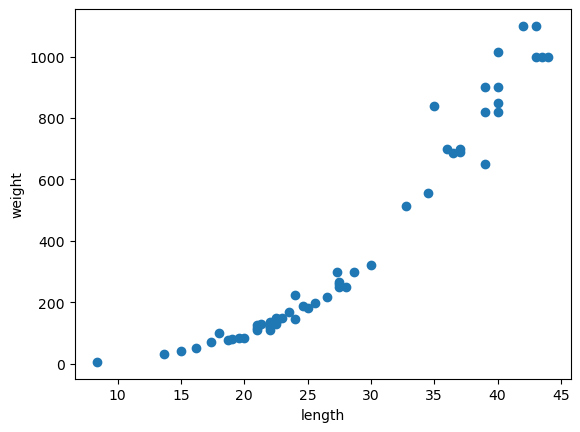

In [3]:
import matplotlib.pyplot as plt

plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

### 1. 데이터 세트 나누기

In [4]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)

- 이번 예제에서는 특성을 1개만 사용하므로 수동으로 2차원 배열을 만들어야 함
- numpy의 `reshape()`에서 크기에 -1을 지정하면 나머지 원소 개수에 맞게 자동으로 차원을 지정함
    - e.g. `train_input.reshape(-1, 1)`은 열은 1개로 고정하고 행은 자동 계산됨

In [5]:
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)
print(train_input.shape, test_input.shape)

(42, 1) (14, 1)


---

## 2. 결정계수(R²)

### 2.1. KNeighborsRegressor

사이킷런에서 k-최근접 이웃 회귀 알고리즘을 구현한 클래스임. 사용법은 `KNeighborsClassifier`와 매우 비슷함. 객체를 생성하고 `fit()` 메서드로 회귀 모델을 훈련함.

In [6]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor()

knr.fit(train_input, train_target)  # k-최근접 이웃 회귀 모델 훈련

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 2.2. 결정계수(R²)

회귀 모델의 점수를 평가하는 지표임. 분류에서는 정확도(정답을 맞힌 개수의 비율)를 사용하지만, 회귀에서는 예측값과 타깃이 모두 임의의 수치이므로 정확히 맞히는 것이 거의 불가능함.

**계산 공식:**

```
R² = 1 - (타깃 - 예측)²의 합 / (타깃 - 평균)²의 합
```

타깃의 평균 정도만 예측하면 R²는 0에 가까워지고, 예측이 타깃에 아주 가까워지면 1에 가까운 값이 됨.

> **참고:** 사이킷런의 `score()` 메서드가 출력하는 값은 높을수록 좋은 것임. 만약 `score()` 메서드가 에러율을 반환한다면 이를 음수로 만들어 실제로는 낮은 에러가 `score()` 메서드로 반환될 때 높은 값이 되도록 바꿈.

In [9]:
print(knr.score(test_input, test_target))

0.992809406101064


### 2.3. 평균 절댓값 오차(MAE)

R²는 직감적으로 얼마나 좋은지 이해하기 어려움. 타깃과 예측한 값 사이의 차이를 구해 보면 어느 정도 예측이 벗어났는지 가늠하기 좋음. `sklearn.metrics` 패키지의 `mean_absolute_error`는 타깃과 예측의 절댓값 오차를 평균하여 반환함.

In [10]:
from sklearn.metrics import mean_absolute_error

test_prediction = knr.predict(test_input)
mae = mean_absolute_error(test_target, test_prediction)
print(mae)

19.157142857142862


즉, 길이를 입력하면 무게를 예측하는 회귀 모델인데, 평균적으로 실제 무게와 예측 무게가 19g 정도 차이난다는 뜻

---

## 3. 과대 적합 & 과소 적합

In [11]:
# 훈련 세트의 결정계수(R²) 점수
print(knr.score(train_input, train_target))

0.9698823289099254


⇒ 훈련 세트에서 모델을 훈련했으므로 훈련 세트에서 더 좋은 점수가 나오는 게 일반적인 현상임

### 3.1. 과대 적합

- 훈련 세트에서 점수가 굉장히 좋았는데 테스트 세트에서는 점수가 굉장히 나쁜 경우
- 즉, 훈련 세트에만 잘 맞는 모델이라 테스트 세트와 나중에 실전에 투입하여 새로운 샘플에 대한 예측을 만들 때 잘 동작하지 않음

### 3.2. 과소 적합

- 훈련 세트보다 테스트 세트의 점수가 높거나 두 점수가 모두 너무 낮은 경우
- 모델이 너무 단순하여 훈련 세트에 적절히 훈련되지 않은 경우
- 훈련 세트가 전체 데이터를 대표한다고 가정하기 때문에 훈련 세트를 잘 학습하는 것이 중요함

#### ∴ 즉, 훈련 세트와 테스트 세트의 점수를 비교했을 때 훈련 세트가 너무 높으면 **과대 적합**, 그 반대이거나 두 점수가 모두 낮으면 **과소 적합**으로 판정함

### 3.3. 해결 방법 (과소 적합)
- 모델을 조금 더 복잡하게 만들면 됨
- 즉, 훈련 세트에 더 잘 맞게 만들면 테스트 세트의 점수는 조금 낮아질 것

In [12]:
# 이웃의 개수를 3으로 설정
knr.n_neighbors = 3

# 모델을 다시 훈련
knr.fit(train_input, train_target)
print(knr.score(train_input, train_target))

0.9804899950518966


⇒ k 값을 줄였더니 훈련 세트의 R² 점수가 높아짐

- k-최근접 이웃 알고리즘으로 모델을 더 복잡하게 만드는 방법은 이웃의 개수 k를 줄이는 것
- 이웃의 개수를 줄이면 훈련 세트에 있는 국지적인 패턴에 민감해지고, 이웃의 개수를 늘리면 데이터 전반에 있는 일반적인 패턴을 따름
- sklearn의 k-최근접 이웃 알고리즘의 기본 k 값은 5

In [13]:
print(knr.score(test_input, test_target))

0.9746459963987609


- 테스트 세트의 점수는 훈련 세트보다 낮아졌으므로 과소적합 문제를 해결한 것!
- 또한 두 점수의 차이가 크지 않으므로 과대적합 된 것 같지도 않음